# Tests de Hipótesis para Una Muestra

## Test de Hipótesis - Una muestra

Hasta ahora cubrimos los *baby steps* de inferencia estadística. Muchas veces lo anterior es suficiente, pero no para nosotros 😎.

En esta sección se cubrirán los **test de hipótesis**. Estos nos permiten probar diferentes *ideas* que se tienen sobre los datos de forma informada.  

Si bien existe una parte profunda, que concierne los tipos de error, eso se verá en la cátedra del curso. En esta sección nos enfocaremos en cómo se implementan los test de hipótesis en `python` y una breve interpretación de los resultados.

### Test Z: Test de hipótesis sobre la media con varianza conocida 

#### Procedimiento

Al igual que para los intervalos de confianza, existe una gran diferencia entre los test de hipótesis para la media con varianza poblacional conocida o no. A partir de este test se introducirán conceptos clave para pode realizar test sobre la muestra con menos datos.

En primer lugar, es necesario generar la hipótesis que se quiere comprobar. En esta primero es necesario generar la **hipótesis nula:**
$$H_0: \mu = \mu_0$$
La cuál plantea que la media poblacional $\mu$ es igual a un valor de referencia $\mu_0$. Luego se define la **hipótesis alternativa**, esta plantea una posibilidad alterna:
$$H_a: \mu \neq \mu_0$$
Notar que, cuando tiene la forma mostrada, con $\neq$ en $H_a$ se dice que es una prueba de dos colas. En cambio, cuando $\neq$ es reemplazado por $<$ o $>$ se denomina de una cola.

Posterior a este procedimiento, es necesario analizar los supuestos. Para poder realizar este test, los datos deben seguir una distribución **casi** normal, y la varianza poblacional debe ser conocida. El primero puede ser verificado con QQ-plots.

En segundo lugar, es necesario computar el estadístico de prueba. Este es una forma de resumir la información con tal de comparar con una distribución de referencia, en este caso, una distribución normal estándar ($\mathcal{N}(0,1)$). En particular, el estadístico de prueba para una prueba Z es:
$$
z_0 = \frac{\overline{X} - \mu_0}{\sigma/\sqrt{n}}
$$ 
Donde $\overline{X}$ es la media de la muestra, $\mu_0$ el valor de referencia, $\sigma$ la desviación estándar de la población y $n$ el tamaño de la muestra. Este estimador, por medio del TLC, posee una distribución normal con media 0 y varianza 1. De esta forma, la distribución de referencia para esta prueba es la antes mencionada. 

Posteriormente, este valor es utilizado para calcular el valor-p de la prueba:
> **Valor-p**
>
> El valor-p es la probabilidad de obtener un resultado tan extremo como el observado (o más), **asumiendo que $H_0$ es verdadera**. En otras palabras, mide qué tan "raro" es el dato que tenemos si la hipótesis nula fuera cierta.
>
> - Un valor-p **pequeño** (típicamente $< \alpha = 0.05$) indica que el resultado observado sería muy improbable bajo $H_0$, por lo que se **rechaza** $H_0$.
> - Un valor-p **grande** indica que el resultado es perfectamente compatible con $H_0$, por lo que **no se rechaza** $H_0$.
>
> ⚠️ El valor-p **no** es la probabilidad de que $H_0$ sea verdadera. Es la probabilidad de los datos dado que $H_0$ es verdadera — esa distinción importa.

Para la prueba-z la forma de computar el valor-p depende de si es una prueba de una o dos colas.
- Para $H_a: \mu \neq \mu_0$: $p-val = 2 (1-\Phi(|z_0|))$ 
- Para $H_a: \mu > \mu_0$: $p-val = 1-\Phi(|z_0|)$
- Para $H_a: \mu < \mu_0$: $p-val = \Phi(|z_0|)$

Donde $\Phi(\cdot)$ es el cdf de una distribución normal con media 0 y varianza 1. Finalmente, si $p-val < \alpha$, donde $\alpha$ es un críterio definido por el usuario, se puede rechazar la hipótesis nula.

> **¿Por qué el valor-p toma esa forma?**
>
> $\Phi(z)$ es la CDF de la Normal estándar, es decir, $\Phi(z) = P(Z \leq z)$. El estadístico $z_0$ resume cuánto se aleja la media muestral de $\mu_0$ en unidades de desviación estándar. Entonces:
>
> - **Dos colas** ($\mu \neq \mu_0$): la evidencia en contra de $H_0$ viene de ambos lados — que $z_0$ sea muy positivo *o* muy negativo. Por eso se calcula $P(Z > |z_0|)$ en la cola derecha y se multiplica por 2 para contar ambas colas simétricamente: $p\text{-val} = 2(1 - \Phi(|z_0|))$.
>
> - **Cola derecha** ($\mu > \mu_0$): solo hay evidencia en contra de $H_0$ si $z_0$ es suficientemente grande y positivo. El valor-p es la probabilidad de obtener un $Z$ aún más grande: $p\text{-val} = 1 - \Phi(z_0) = P(Z > z_0)$.
>
> - **Cola izquierda** ($\mu < \mu_0$): análogo al caso anterior, pero la evidencia viene de valores muy negativos. El valor-p es la probabilidad de obtener un $Z$ aún más pequeño: $p\text{-val} = \Phi(z_0) = P(Z \leq z_0)$.
>
> En los tres casos, el valor-p mide el área bajo la curva normal en la región "más extrema que $z_0$", según la dirección que plantea $H_a$.

Ahora programemos esto en python:

In [81]:
# muestra aleatoria 
np.random.seed(42)  # Para reproducibilidad
muestra = np.random.normal(loc=10, scale=2, size=30)  # muestra de tamaño 30 de una población normal
varianza_poblacional = 2**2
# hipotesis
# H_0: mu = 11 
# H_a: mu < 11 
# estadistico de prueba
mu0 = 11
media_muestral = np.mean(muestra)
z = (media_muestral - mu0) / (np.sqrt(varianza_poblacional) / np.sqrt(len(muestra)))
p_valor = stats.norm.cdf(z)  # P(Z < z) para una prueba de cola izquierda
print(f"Estadístico de prueba z: {z:.4f}")
print(f"P-valor: {p_valor:.4f}")


Estadístico de prueba z: -3.7691
P-valor: 0.0001


Dado que el valor-p es menor a $\alpha = 0.05$, podemos rechazar la hipótesis nula y aceptamos la alternativa.

Lamentablemente, no encontré ningún paquete que tuviera una implementación correcta, para hacer este tipo de test utilice la siguiente función:

In [ ]:
def ztest_1samp(dato1, mu0, pop_var = 1, significance = 0.05 ,alternative = 'two-sided'):
    '''
    Z-test para una muestra. 
    
    Este test asume varianzas poblacionales conocidas, que las muestras son independientes
    y siguen una distribución normal.
    ---
    Parámetros:
        dato1 : array_like
            Primera muestra de datos.
        mu0 : float
            Valor hipotético de la media poblacional.
        pop_var : float, optional
            Varianza poblacional. Por defecto es 1.
        alternative : str, optional
            Tipo de test de hipótesis a realizar. Puede ser 'two-sided', 'larger' o 'smaller'.
            Por defecto es 'two-sided'.

    Retorna:
        z : float
            Valor del estadístico z.
        p_value : float
            Valor p del test.
    '''
    mean1 = np.mean(dato1)

    n1 = len(dato1)


    z = (mean1 - mu0) / np.sqrt(pop_var/n1)

    if alternative == 'two-sided':
        p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))
    elif alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z)
    else:
        raise ValueError("El valor de 'alternative' debe ser 'two-sided', 'larger' o 'smaller'.")

    return z, p_value

# Ejemplo de uso
# para los datos anteriores
z, p_value = ztest_1samp(muestra, mu0=11, pop_var=4, alternative='smaller')
print(f"Z-test: z = {z:.4f}, p-value = {p_value:.4f}")

Z-test: z = -3.7691, p-value = 0.0001


#### Error de tipo 2 y tamaño de muestra
Ahora, para calcular la probabilidad de tipo 2 (fallar en rechazar $H_0$ cuando este es falso). Esta probabilidad puede computarse de la siguiente forma:

$$
\beta = \Phi\left(z_{\alpha/2} - \frac{\delta \sqrt{n}}{\sigma}\right) - \Phi\left(-z_{\alpha/2} - \frac{\delta \sqrt{n}}{\sigma}\right) 
$$

Donde $\delta = \mu - \mu_0$ es la diferencia real entre la media verdadera y el valor de referencia $\mu_0$. Este valor **no se estima desde los datos**, sino que se define antes de recolectarlos como la diferencia mínima que tiene relevancia práctica detectar. De esta manera, con el valor $\delta$ fijado, la probabilidad $\beta$ corresponde a la probabilidad de que el test no detecte una diferencia que en realidad existe — es decir, la probabilidad de cometer un **error tipo II**. 

El complemento de $\beta$, $1 - \beta$, se denomina **potencia del test** y es lo que en la práctica se quiere maximizar. Una aplicación directa de esto es determinar el **tamaño de muestra necesario** para detectar una diferencia $\delta$ con una potencia $1 - \beta$ deseada. Para una prueba de dos colas:

$$n \approx \frac{(z_{\alpha/2} + z_{\beta})^2 \,\sigma^2}{\delta^2}$$

Y para una prueba de una cola:

$$n = \frac{(z_{\alpha} + z_{\beta})^2 \,\sigma^2}{\delta^2}$$

donde $z_\beta$ es el percentil superior $\beta$ de la normal estándar. Si $n$ no es entero, se redondea hacia arriba. Nótese que estos resultados encapsulan el balance entre $\alpha$, $\beta$, $\delta$ y $\sigma$: para detectar diferencias más pequeñas, o para cometer menos errores de ambos tipos, se requiere una muestra más grande.

#### Curvas de Operación Característica (OC Curves)

Las **curvas OC** son una herramienta gráfica que relaciona la probabilidad de error tipo II ($\beta$) con el parámetro $d$, definido como la diferencia estandarizada entre la media real y la de referencia:

$$d = \frac{|\mu - \mu_0|}{\sigma} = \frac{|\delta|}{\sigma}$$

Al estandarizar con $\sigma$, las curvas son universales — sirven para cualquier problema independiente de las unidades. Cada curva corresponde a un tamaño de muestra $n$ distinto, y permiten responder dos preguntas prácticas:

- **Dado $n$ y $d$, ¿cuál es $\beta$?** -> Útil cuando el tamaño de muestra ya está fijo por restricciones económicas o experimentales.
- **Dado $\beta$ y $d$, ¿cuál es el $n$ necesario?** -> Útil al diseñar un experimento para alcanzar una potencia deseada.

De las curvas se desprenden dos conclusiones intuitivas: diferencias más grandes ($d$ mayor) son más fáciles de detectar, y muestras más grandes reducen $\beta$ para cualquier $d$.

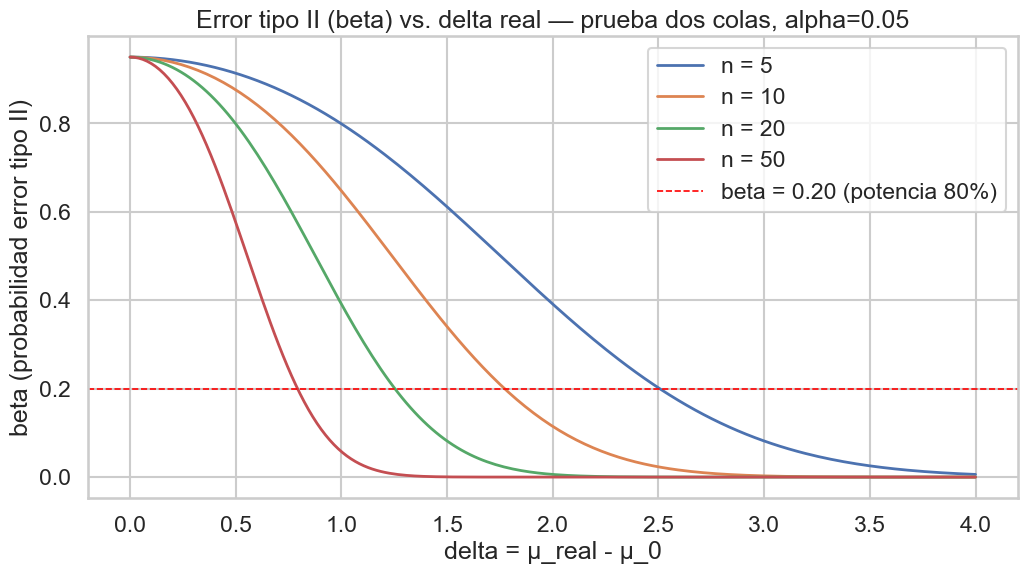

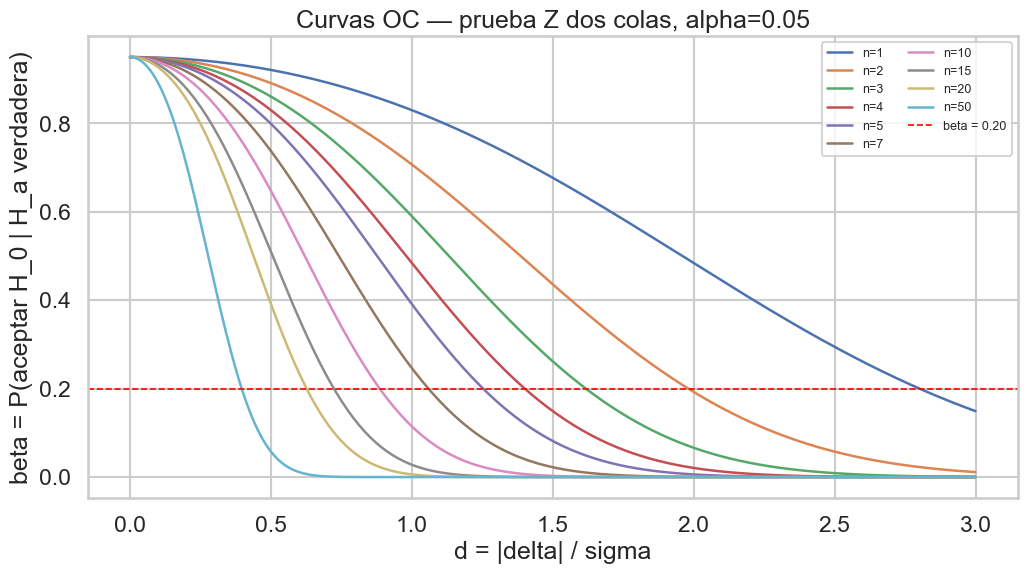

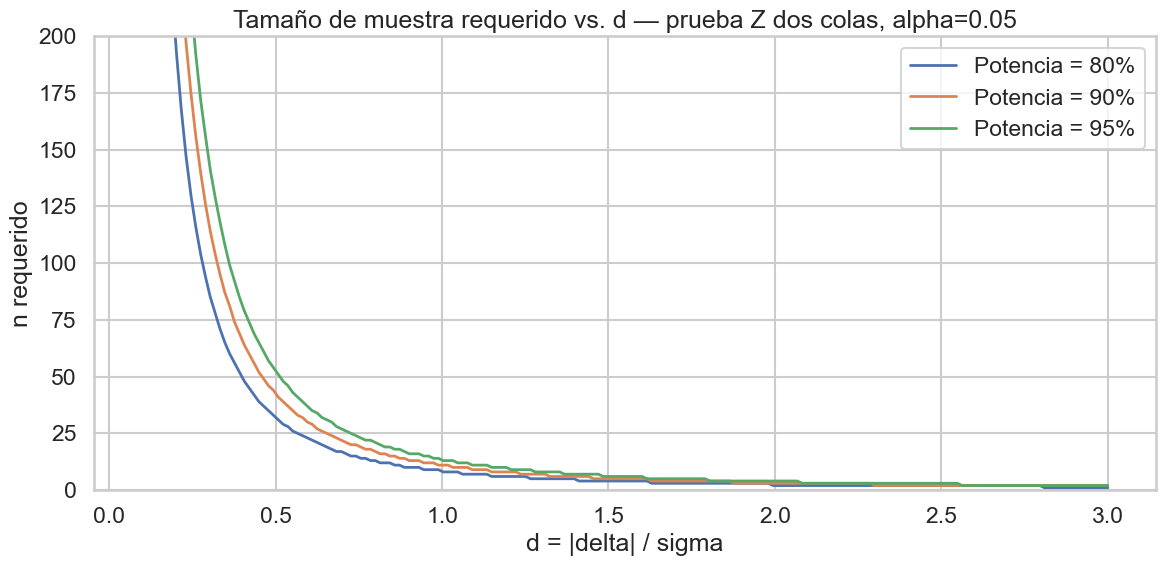

 Ejemplo numérico
 μ0=10, sigma=2, delta=1.5, alpha=0.05
 d = |delta|/sigma = 0.750

  Con n=15:
 beta = 0.1724 -> potencia = 82.8%

 Para potencia >= 80% (beta ≤ 0.20):
 n mínimo requerido = 14


In [63]:


# ------- Parámetros del problema -------
mu_0  = 10      # media bajo H_0
sigma = 2       # desviación estándar poblacional (conocida)
alpha = 0.05    # nivel de significancia
z_a2  = stats.norm.ppf(1 - alpha/2)   # z_{alpha/2}

# -------
# 1. EFECTO DE delta Y n SOBRE beta
# -------
deltas = np.linspace(0, 4, 200)   # diferencias reales a evaluar (mu - mu0)
n_vals = [5, 10, 20, 50]          # tamaños de muestra (n)

fig, ax = plt.subplots(figsize=(12, 6))

for n in n_vals:
    betas = []
    for delta in deltas:
        term = delta * np.sqrt(n) / sigma
        # dado el tamaño de muestra n
        # dado la diferencia con respecto a H_0 y real (delta)
        # que error de tipo 2 tengo?
        beta = stats.norm.cdf(z_a2 - term) - stats.norm.cdf(-z_a2 - term) 
        beta = max(beta, 0)   # numérico: evitar valores negativos diminutos
        betas.append(beta)
    ax.plot(deltas, betas, linewidth=2, label=f'n = {n}')

ax.axhline(0.2, color='red', linestyle='--', linewidth=1.2, label='beta = 0.20 (potencia 80%)')
ax.set_title(f'Error tipo II (beta) vs. delta real — prueba dos colas, alpha={alpha}')
ax.set_xlabel('delta = µ_real - μ_0')
ax.set_ylabel('beta (probabilidad error tipo II)')
ax.legend()
# plt.tight_layout()
plt.show()

# ----------
# 2. CURVAS OC — β vs d estandarizado
# ----------
d_vals = np.linspace(0, 3, 300)   # d = |delta| / sigma

fig, ax = plt.subplots(figsize=(12, 6))

for n in [1, 2, 3, 4, 5, 7, 10, 15, 20, 50]:
    betas = []
    for d in d_vals:
        delta = d * sigma
        term  = delta * np.sqrt(n) / sigma
        # dado un ta
        beta  = stats.norm.cdf(z_a2 - term) - stats.norm.cdf(-z_a2 - term)
        betas.append(max(beta, 0))
    ax.plot(d_vals, betas, linewidth=1.8, label=f'n={n}')

ax.axhline(0.2, color='red', linestyle='--', linewidth=1.2, label='beta = 0.20')
ax.set_title(f'Curvas OC — prueba Z dos colas, alpha={alpha}')
ax.set_xlabel('d = |delta| / sigma')
ax.set_ylabel('beta = P(aceptar H_0 | H_a verdadera)')
ax.legend(fontsize=9, ncol=2, loc='upper right')
# plt.tight_layout()
plt.show()

# ---------
# 3. TAMAÑO DE MUESTRA necesario para alcanzar potencia deseada
# ---------
potencias  = [0.80, 0.90, 0.95]
d_grid     = np.linspace(0.1, 3, 200)

fig, ax = plt.subplots(figsize=(12, 6))

for potencia in potencias:
    beta_obj = 1 - potencia
    z_b = stats.norm.ppf(1 - beta_obj)   # z_beta
    n_req = np.ceil((z_a2 + z_b)**2 / d_grid**2).astype(int)
    ax.plot(d_grid, n_req, linewidth=2, label=f'Potencia = {int(potencia*100)}%')

ax.set_title(f'Tamaño de muestra requerido vs. d — prueba Z dos colas, alpha={alpha}')
ax.set_xlabel('d = |delta| / sigma')
ax.set_ylabel('n requerido')
ax.set_ylim(0, 200)
ax.legend()
plt.tight_layout()
plt.show()

# ---------
# 4. EJEMPLO NUMÉRICO COMPLETO
# ---------
delta_real = 1.5   # diferencia que se quiere detectar
n_ej       = 15    # tamaño de muestra disponible
beta_obj   = 0.20  # error tipo II máximo tolerable

# Beta para n y delta dados
term  = delta_real * np.sqrt(n_ej) / sigma
beta_ej = stats.norm.cdf(z_a2 - term) - stats.norm.cdf(-z_a2 - term)

# n necesario para beta = 0.20
z_b   = stats.norm.ppf(1 - beta_obj)
d_ej  = delta_real / sigma
n_min = int(np.ceil((z_a2 + z_b)**2 / d_ej**2))

print("============")
print(" Ejemplo numérico")
print("============")
print(f" μ0={mu_0}, sigma={sigma}, delta={delta_real}, alpha={alpha}")
print(f" d = |delta|/sigma = {d_ej:.3f}")
print()
print(f"  Con n={n_ej}:")
print(f" beta = {beta_ej:.4f} -> potencia = {1-beta_ej:.1%}")
print()
print(f" Para potencia >= 80% (beta ≤ 0.20):")
print(f" n mínimo requerido = {n_min}")


>**¿Cómo se leen?** **Curva OC**
>
>El eje horizontal es $d$ y el vertical es $\beta$. Para un $n$ fijo, la curva cae de izquierda a derecha: cuando $d = 0$ la diferencia real es nula y $\beta \approx 1 - \alpha$ (casi nunca se rechaza $H_0$, lo cual es correcto), y a medida que $d$ crece la curva cae hacia cero — diferencias grandes son cada vez más fáciles de detectar. Curvas más a la izquierda corresponden a $n$ mayores, lo que refleja que con más datos se detectan diferencias pequeñas con mayor facilidad.

> **¿Cómo se lee?** **Curva tamaño de muestra**
> 
> El eje horizontal es $d = |\delta|/\sigma$ y el vertical es el $n$ mínimo requerido. Cada curva corresponde a una potencia objetivo distinta. La forma es siempre decreciente: cuando $d$ es pequeño (diferencia difícil de detectar) se necesita una muestra muy grande, y a medida que $d$ crece el $n$ requerido cae rápidamente. Curvas más altas corresponden a potencias más exigentes — pedir 95% de potencia siempre requiere más datos que pedir 80%. Una lectura típica es: fijar la potencia deseada, ubicar el $d$ de interés en el eje horizontal, y leer el $n$ en el eje vertical.


### Test T: Test de hipótesis sobre la media con varianza desconocida
#### Procedimiento
Este test trabaja sobre la misma hipótesis del test Z, salvo que ahora, la varianza poblacional no es conocida. Notar que los datos deben seguir siendo **casi** normales.

Al igual que cuando calculamos intervalos de confianza con varianza desconocida, este test utiliza la distribución $t$ como distribución de referencia. En específico, el test ocupa el siguiente estadístico:

$$
t_0 = \frac{\overline{X} - \mu_0}{S/\sqrt{n}}
$$

Donde $\overline{X}$ es la media muestral, $\mu_0$ el valor de referencia, $S$ la desciación estándar muestral y $n$ el tamaño de la muestra. Este estadístico de prueba es comparado frente a una distribución $t$ con $n-1$ grafos de libertad.

Finalmente, para calcular el valor-p se tienen las siguientes cantidades para cada tipo de hipótesis alternativa. Considerando que
$$H_0: \mu = \mu_0$$
Entonces:
- $H_a: \mu\neq \mu_0$: $p-val = 2P(T_{n-1} > |t_0|)$
- $H_a: \mu > \mu_0$: $p-val = P(T_{n-1} > t_0)$
- $H_a: \mu <  \mu_0$:$p-val = P(T_{n-1} < t_0)$

Donde $T_{n-1}$ hace referencia a una una variable aleatoria que sigue una distribución $T$ con $n-1$ grados de libertad. Para poder entender mejor estas definiciones, se puede ver el siguiente código.

In [64]:
# asumiendo que 
t_0 = 2.5 # valor arbitrario del estadístico t calculado a partir de los datos
nu = 20   # grados de libertad (n-1)
# cuando H_a: mu != mu0 (prueba dos colas)
p_valor_dos_colas = 2 * (1 - stats.t.cdf(np.abs(t_0), df=nu))

Antes de seguir, notemos que:
$$P(T_{n-1} > |t_0|) = 1- P(T_{n-1}\leq |t_0|)$$
Donde $P(T_{n-1}\leq |t_0|)$ cual es el CDF de la distribución T con $n-1$ grados de libertas evaluado en $|t_0|$. 

In [65]:
print(f"Prueba dos colas: t_0 = {t_0}, nu = {nu} -> p-valor = {p_valor_dos_colas:.4f}")
# para H_a: mu > mu0 (prueba cola derecha)
p_valor_cola_derecha = 1 - stats.t.cdf(t_0, df=nu)
print(f"Prueba cola derecha: t_0 = {t_0}, nu = {nu} -> p-valor = {p_valor_cola_derecha:.4f}")
# para H_a: mu < mu0 (prueba cola izquierda)
p_valor_cola_izquierda = stats.t.cdf(t_0, df=nu)
print(f"Prueba cola izquierda: t_0 = {t_0}, nu = {nu} -> p-valor = {p_valor_cola_izquierda:.4f}")


Prueba dos colas: t_0 = 2.5, nu = 20 -> p-valor = 0.0212
Prueba cola derecha: t_0 = 2.5, nu = 20 -> p-valor = 0.0106
Prueba cola izquierda: t_0 = 2.5, nu = 20 -> p-valor = 0.9894


Finalmente, el valor-p se compara como en un test z. 

Este procedimiento en acción se ve así:

In [66]:
np.random.seed(42) # Para reproducibilidad
# datos aleatorios 
grupo_A = np.random.normal(loc=10, scale=2, size=30000)  # Grupo A (n=30)
muestra = np.random.choice(grupo_A, size=30, replace=False)  # muestra aleatoria de tamaño 30
mu0 = 11  # media bajo H_0
# H_0: mu = 11
# H_a: mu < 11

# estadistico de prueba
media_muestral = np.mean(muestra)
std_muestral = np.std(muestra, ddof=1)
t_0 = (media_muestral - mu0) / (std_muestral / np.sqrt(len(muestra)))
nu = len(muestra) - 1

# p-valor para prueba de cola izquierda
p_valor = stats.t.cdf(t_0, df=nu)
print(f"Estadístico de prueba t: {t_0:.4f}")
print(f"P-valor (prueba cola izquierda): {p_valor:.4f}")

Estadístico de prueba t: -2.5529
P-valor (prueba cola izquierda): 0.0081


Lo bueno, es que este test es posible realizarlo con paquetes externos :D. Por lo cual no es necesario hacer todos los cálculos.

In [67]:
# con scipy
# importante que alternative define el tipo de test.
# 'less' para H_a: mu < mu0
# 'greater' para H_a: mu > mu0
# 'two-sided' para H_a: mu != mu0
res = stats.ttest_1samp(muestra,  # datos a evaluar
                        popmean=mu0, # media bajo H_0
                        alternative='less'
                        )
# res corresponde a un objeto con atributos 'statistic' (valor t) y 'pvalue' (p-valor) y 'df' (grados de libertad)
print(f"Scipy t-test: t = {res.statistic:.4f}, p-value = {res.pvalue:.4f}")


Scipy t-test: t = -2.5529, p-value = 0.0081


In [68]:
# con pingouin
# El test con pingouin es similar a scipy pero con una sintaxis diferente.
# en este caso y corresponde a con que se compara
# si y es un valor escalar, se asume que es la media bajo H_0 (mu0)
# si y es un array, se asume que es la segunda muestra (para test de muestras independientes) 
#       El cual veremos mas adelante
# el alternative es el mismo que en scipy: 'less', 'greater' o 'two-sided'

ttest_results = pg.ttest(muestra, # los datos 
                         y=mu0, # si es 
                         alternative='less')
# el resultado es un DataFrame con varias columnas, entre ellas 'T' (valor t) y 'p-val' (p-valor)
display(ttest_results) # muestra el DataFrame con los resultados del test
# podemos imprimirlo tambien
print(f"Pingouin t-test: t = {ttest_results.loc['T_test', 'T']:.4f}, p-value = {ttest_results.loc['T_test', 'p_val']:.4f}")

,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-2.552913,29,less,0.008103,"[-inf, 10.67]",0.466096,0.801717


Pingouin t-test: t = -2.5529, p-value = 0.0081


Notemos que todas las implementaciones previas dieron lo mismo :D.

#### Error de tipo 2 y tamaño de muestra

En el caso del **test-t** (varianza desconocida), $\beta$ se calcula usando la **distribución t no central**, cuyo parámetro de no centralidad es $\lambda = d\sqrt{n}$. En la práctica, este cómputo no es sencillo, pero librerías de Python pueden realizarlo por nosotros :D. En el siguiente bloque se verá un ejemplo de aquello.

En resumidas cuentas, lo que pasa por detrás es:

> Formalmente, dado el parámetro de no centralidad $\lambda = d\sqrt{n}$ y los grados de libertad $\nu = n-1$, la potencia del test de dos colas se calcula como:
>
> $$1 - \beta = \underbrace{P(T > t_{\alpha/2,\,\nu} \mid \lambda)}_{\texttt{nct.sf}(t_{crit},\ \nu,\ \lambda)} + \underbrace{P(T < -t_{\alpha/2,\,\nu} \mid \lambda)}_{\texttt{nct.cdf}(-t_{crit},\ \nu,\ \lambda)}$$
>
> donde $T \sim t_{nc}(\nu,\ \lambda)$ es una distribución $t$ no central, y el valor crítico $t_{\alpha/2,\,\nu}$ se obtiene como:
>
> $$t_{\alpha/2,\,\nu} = F_t^{-1}\!\left(1 - \frac{\alpha}{2};\ \nu\right) \quad \longleftrightarrow \quad \texttt{stats.t.ppf}(1 - \alpha/2,\ df)$$
>
> Por lo tanto, $\beta$ corresponde al área de la distribución $t$ no central que **no** supera los valores críticos — es decir, la región donde el test no logra detectar la diferencia real.


In [69]:
alpha = 0.05 # significancia
delta = 1.5 # diferencia real entre la media bajo H_0 y la media real (delta = |mu_real - mu0|)
s = 2.0 # desviación estándar poblacional (o una estimación de ella)
d = delta / s # effect size = |delta| / s


# pingouin: the readable approach

# Given n, find power
power = pg.power_ttest(d=d, n=15, alpha=alpha, alternative='two-sided', contrast = 'one-sample')
print(f"Power con n=15: {power:.4f}")
print(f"beta con n=15: {1-power:.4f}")

# Given power, find n
n_required = pg.power_ttest(d=d, power=0.80, alpha=alpha, alternative='two-sided', contrast = 'one-sample')
print(f"\nN requerido para 80% power: {int(np.ceil(n_required))}")

# 
# Option 2 — scipy: manual con non-central t
# Srive para entender como funciona
# 
def power_ttest_scipy(d, n, alpha, two_sided=True):
    """
    Este código calcula la potencia de una prueba t de una muestra utilizando la distribución t no central.
    Lo importante es entender que la potencia se calcula como el área bajo la curva de la distribución t no central
    más allá de los valores críticos definidos por el nivel de significancia alpha.
    Parámetros:
        d : effect size = |delta| / s
        n : sample size
        alpha : significance level
    """
    df = n - 1 # grados de libertad
    lam = d * np.sqrt(n) # parámetro de no centralidad
    t_crit = stats.t.ppf(1 - alpha/2, df=df) # t crítico para prueba de dos colas

    # Power = area of non-central t beyond the critical values
    power = stats.nct.sf(t_crit, df=df, nc=lam) # P(T > t_crit | H1)
    if two_sided:
        power += stats.nct.cdf(-t_crit, df=df, nc=lam)  # + P(T < -t_crit | H1)
    return power

power_scipy = power_ttest_scipy(d=d, n=15, alpha=alpha)
print(f"\nPower (scipy manual):{power_scipy:.4f}")

Power con n=15: 0.7707
beta con n=15: 0.2293

N requerido para 80% power: 16

Power (scipy manual):0.7707


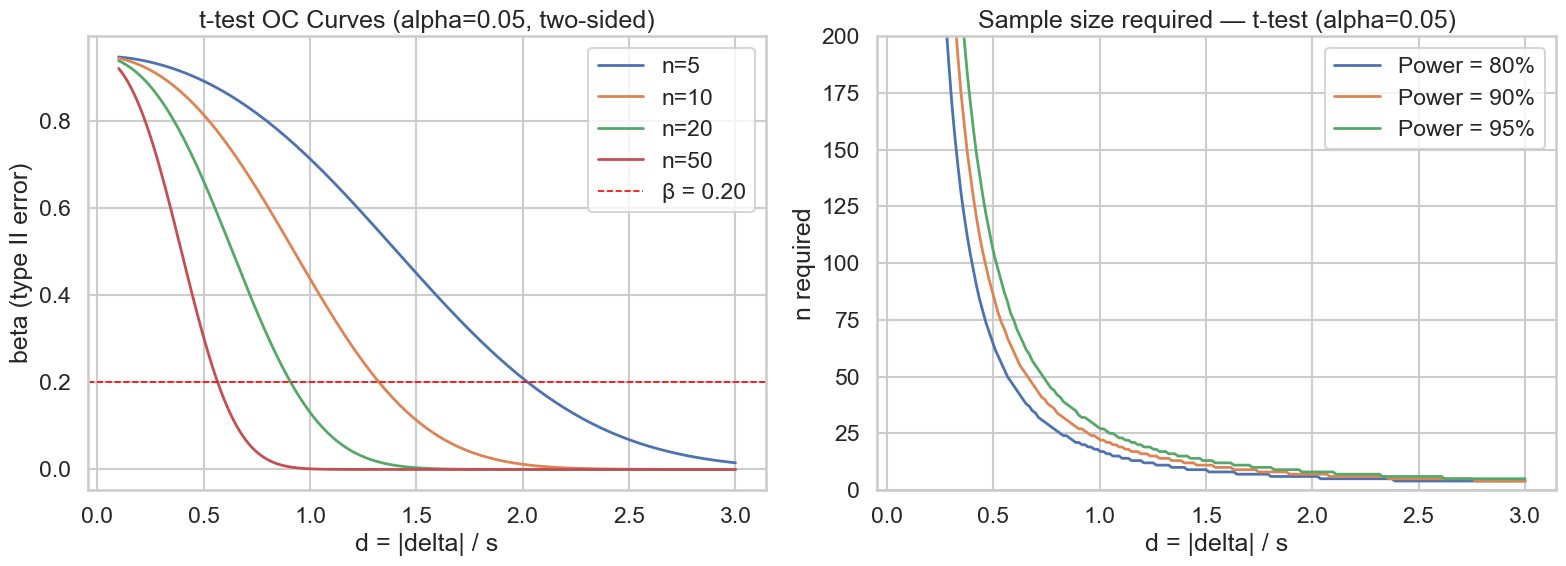

In [70]:

# -----
# curvas OC y tamaño de muestra requerido con pingouin
# ------
d_grid = np.linspace(0.1, 3, 200)
n_vals = [5, 10, 20, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculamos el valor de beta (error tipo II) para cada combinación de d y n
for n in n_vals:
    betas = [1 - pg.power_ttest(d=d_val, n=n, alpha=alpha, alternative='two-sided')
             for d_val in d_grid]
    axes[0].plot(d_grid, betas, linewidth=2, label=f'n={n}')

axes[0].axhline(0.2, color='red', linestyle='--', linewidth=1.2, label='β = 0.20')
axes[0].set_title(f't-test OC Curves (alpha={alpha}, two-sided)')
axes[0].set_xlabel('d = |delta| / s')
axes[0].set_ylabel('beta (type II error)')
axes[0].legend()

# Right: n required vs d for different target powers
for potencia in [0.80, 0.90, 0.95]:
    n_reqs = [int(np.ceil(pg.power_ttest(d=d_val, power=potencia, alpha=alpha, alternative='two-sided')))
              for d_val in d_grid]
    axes[1].plot(d_grid, n_reqs, linewidth=2, label=f'Power = {int(potencia*100)}%')

axes[1].set_title(f'Sample size required — t-test (alpha={alpha})')
axes[1].set_xlabel('d = |delta| / s')
axes[1].set_ylabel('n required')
axes[1].set_ylim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

### Test de Varianza: Test de hipótesis sobre la varianza
#### Procedimiento
Este test permite verificar si la varianza poblacional $\sigma^2$ es igual a un valor de referencia $\sigma^2_0$. Al igual que el test-t, los datos deben provenir de una distribución **normal**.

A diferencia de los tests sobre la media, este test utiliza la distribución $\chi^2$ como distribución de referencia. En específico, el test ocupa el siguiente estadístico:

$$
\chi^2_0 = \frac{(n-1)S^2}{\sigma^2_0}
$$

Donde $S^2$ es la varianza muestral, $\sigma^2_0$ el valor de referencia bajo $H_0$ y $n$ el tamaño de la muestra. Este estadístico de prueba es comparado frente a una distribución $\chi^2$ con $n-1$ grados de libertad.

Finalmente, para calcular el valor-p se tienen las siguientes cantidades para cada tipo de hipótesis alternativa. Considerando que
$$H_0: \sigma^2 = \sigma^2_0$$
Entonces:
- $H_a: \sigma^2 \neq \sigma^2_0$: $p\text{-val} = 2\min\!\left(P(\chi^2_{n-1} > \chi^2_0),\ P(\chi^2_{n-1} < \chi^2_0)\right)$
- $H_a: \sigma^2 > \sigma^2_0$: $p\text{-val} = P(\chi^2_{n-1} > \chi^2_0)$
- $H_a: \sigma^2 < \sigma^2_0$: $p\text{-val} = P(\chi^2_{n-1} < \chi^2_0)$

Donde $\chi^2_{n-1}$ hace referencia a una variable aleatoria que sigue una distribución $\chi^2$ con $n-1$ grados de libertad. Para poder entender mejor estas definiciones, se puede ver el siguiente código.

In [71]:
# tomando el caso de un estadistico chi2_0 = 1.5
# y un tamaño de muestra n = 30 (grados de libertad nu = 29)
chi2_0 = 12
nu = 29
# H_0: var = var0
# H_a: var > var0
# p-val
p_valor_chi2 = 1 - stats.chi2.cdf(chi2_0, df=nu)
print(f"Chi-cuadrado test (H_a: var > var0): chi2_0 = {chi2_0}, nu = {nu} -> p-valor = {p_valor_chi2:.4f}")
# H_a: var < var0
p_valor_chi2_izquierda = stats.chi2.cdf(chi2_0, df=nu)
print(f"Chi-cuadrado test (H_a: var < var0): chi2_0 = {chi2_0}, nu = {nu} -> p-valor = {p_valor_chi2_izquierda:.4f}")
# H_a: var != var0
p_valor_chi2_dos_colas = 2 * min(p_valor_chi2, p_valor_chi2_izquierda)
print(f"Chi-cuadrado test (H_a: var != var0): chi2_0 = {chi2_0}, nu = {nu} -> p-valor = {p_valor_chi2_dos_colas:.4f}")

Chi-cuadrado test (H_a: var > var0): chi2_0 = 12, nu = 29 -> p-valor = 0.9977
Chi-cuadrado test (H_a: var < var0): chi2_0 = 12, nu = 29 -> p-valor = 0.0023
Chi-cuadrado test (H_a: var != var0): chi2_0 = 12, nu = 29 -> p-valor = 0.0045


Ahora veamos en acción este test de hipótesis.

In [72]:
# valores aleatorios
np.random.seed(42)
poblacion = np.random.normal(loc=10, scale=5, size=100000)  # población normal con varianza 25
muestra = np.random.choice(poblacion, size=30, replace=False)  # muestra aleatoria de tamaño 30
var_muestral = np.var(muestra, ddof=1)  # varianza muestral
# nuestra hipotesis nula
# H_0: var = 25
# H_a: var != 25
var0 = 25
nu = len(muestra) - 1
chi2_0 = (nu * var_muestral) / var0
p_valor_izquierda = stats.chi2.cdf(chi2_0, df=nu)
p_valor_derecha = 1 - stats.chi2.cdf(chi2_0, df=nu)
p_valor_dos_colas = 2 * min(p_valor_izquierda, p_valor_derecha)
print(f"Chi-cuadrado test para varianza: chi2_0 = {chi2_0:.4f}, nu = {nu}")
print(f"p-valor (H_a: var != var0): {p_valor_dos_colas:.4f}")

Chi-cuadrado test para varianza: chi2_0 = 30.9949, nu = 29
p-valor (H_a: var != var0): 0.7313


Para simplificar la realización del test es posible utilizar la siguiente función.

In [92]:
def vartest_1samp(dato1, var0, alternative='two-sided'):
    """
    Test de hipótesis para la varianza de una muestra.
    Parámetros:
        dato1 : array_like
            Primera muestra de datos.
        var0 : float
            Valor hipotético de la varianza poblacional.
        alternative : str, optional
            Tipo de test de hipótesis a realizar. Puede ser 'two-sided', 'greater' o 'less'.
            Por defecto es 'two-sided'.
    Retorna:
        chi2_stat : float
            Valor del estadístico chi-cuadrado.
        p_value : float
            Valor p del test.
    """
    n = len(dato1)
    var_muestral = np.var(dato1, ddof=1)  # varianza muestral
    chi2_stat = (n - 1) * var_muestral / var0  # estadístico chi-cuadrado

    if alternative == 'two-sided':
        p_value = 2 * min(stats.chi2.cdf(chi2_stat, df=n-1), 1 - stats.chi2.cdf(chi2_stat, df=n-1))
    elif alternative == 'greater':
        p_value = 1 - stats.chi2.cdf(chi2_stat, df=n-1)
    elif alternative == 'less':
        p_value = stats.chi2.cdf(chi2_stat, df=n-1)
    else:
        raise ValueError("El valor de 'alternative' debe ser 'two-sided', 'greater' o 'less'.")

    return chi2_stat, p_value


#### Error de tipo II y tamaño de muestra para el test de varianza

Al igual que en los tests sobre la media, es posible calcular $\beta$ y el tamaño de muestra necesario para el test sobre la varianza. La diferencia es que ahora el parámetro estandarizado no es $d$ sino $\lambda$, definido como la razón entre la desviación estándar real y la de referencia:

$$\lambda = \frac{\sigma}{\sigma_0}$$

donde $\sigma$ es el valor real que se quiere detectar y $\sigma_0$ es el valor bajo $H_0$. Nótese que $\lambda = 1$ implica que no hay diferencia real ($\sigma = \sigma_0$), mientras que $\lambda \neq 1$ indica que la varianza real se aleja del valor de referencia.

La intuición es la misma que antes: $\beta$ disminuye cuando $\lambda$ se aleja de 1 (diferencia más grande) o cuando $n$ aumenta (más datos). En Python, este cálculo se realiza usando la **distribución chi-cuadrado no central**, de forma análoga a como el test-t usaba la distribución $t$ no central.

Lamentablemente, de nuevo, no hay paquete externo que permita acceder a este tipo de metodos, pero aquí abajo está una implementación manual.

In [73]:

def power_chi2_var(sigma, sigma_0, n, alpha, two_sided=True):
    """
    Potencia del test chi2 sobre varianza.
    Bajo H1, (n-1)S²/σ₀² = λ² * chi2(n-1), donde λ = σ/σ₀.
    Por lo tanto se escalan los valores críticos dividiéndolos por λ².
    """
    df = n - 1
    lam2 = (sigma / sigma_0)**2  

    # Valores críticos bajo H_0
    chi2_low  = stats.chi2.ppf(alpha/2, df=df)
    chi2_high = stats.chi2.ppf(1 - alpha/2, df=df)

    # Bajo H_1 se escalan los límites críticos
    if two_sided:
        power = (stats.chi2.cdf(chi2_low / lam2, df=df) +
                 stats.chi2.sf( chi2_high / lam2, df=df))
    else:
        power = stats.chi2.sf(chi2_high / lam2, df=df)
    return power

sigma_0 = 0.10
sigma_real = 0.125
alpha = 0.05
n_ej = 20

lam = sigma_real / sigma_0
power_ej = power_chi2_var(sigma_real, sigma_0, n_ej, alpha)

print(f"lambda = sigma/sigma_0 = {lam:.2f}")
print(f"Potencia con n={n_ej}: {power_ej:.4f}")
print(f"beta con n={n_ej}: {1-power_ej:.4f}")


lambda = sigma/sigma_0 = 1.25
Potencia con n=20: 0.3368
beta con n=20: 0.6632


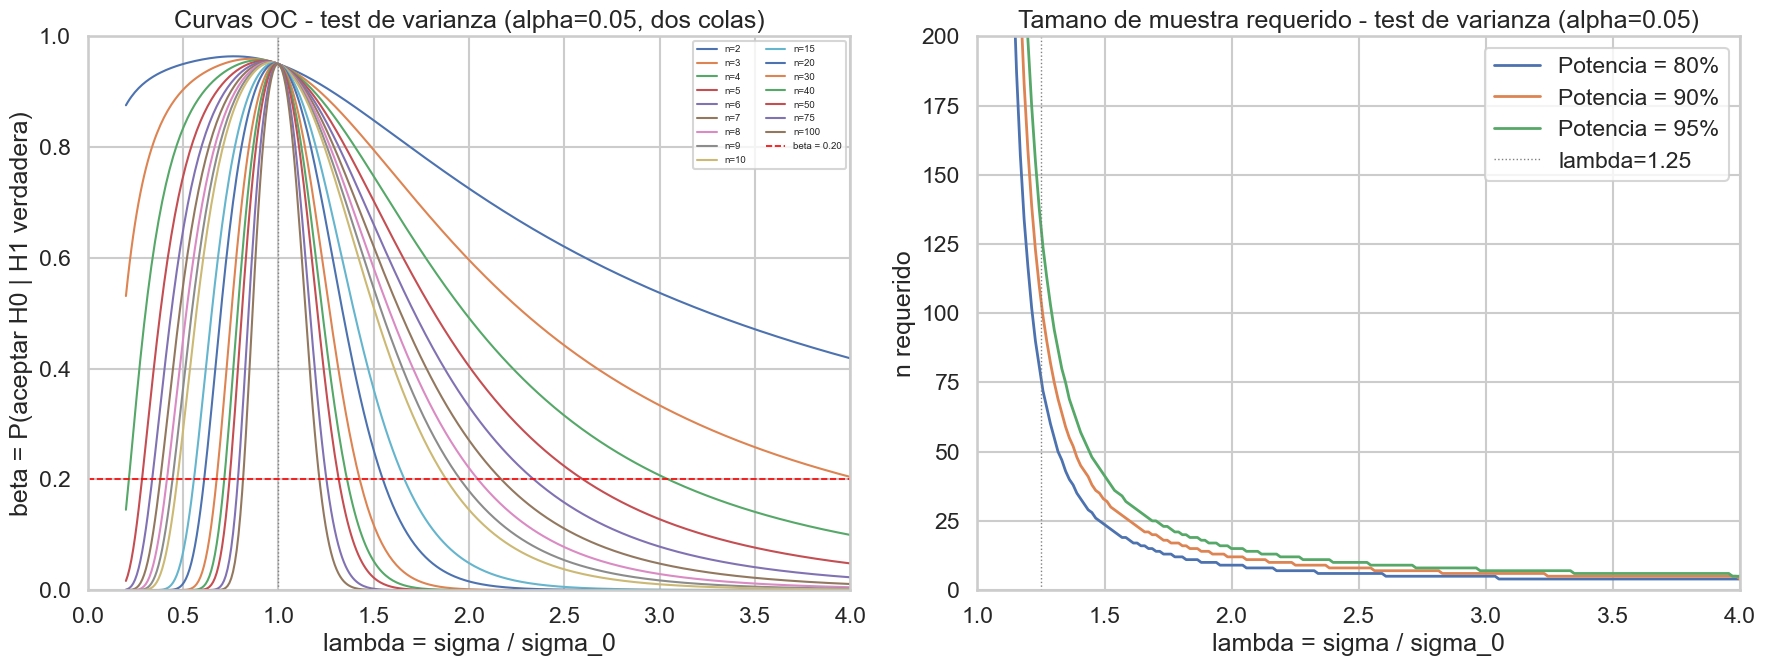

In [74]:
lambda_grid = np.linspace(0.2, 4.0, 400)
n_vals = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 75, 100]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: OC Curves
for n in n_vals:
    betas = [1 - power_chi2_var(lam * sigma_0, sigma_0, n, alpha)
             for lam in lambda_grid]
    axes[0].plot(lambda_grid, betas, linewidth=1.5, label=f'n={n}')

axes[0].axvline(1.0, color='gray', linestyle=':', linewidth=1)
axes[0].axhline(0.2, color='red', linestyle='--', linewidth=1.2, label='beta = 0.20')
axes[0].set_title(f'Curvas OC - test de varianza (alpha={alpha}, dos colas)')
axes[0].set_xlabel('lambda = sigma / sigma_0')
axes[0].set_ylabel('beta = P(aceptar H0 | H1 verdadera)')
axes[0].set_xlim(0, 4.0)
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=7, ncol=2, loc='upper right')

# Right: sample size required vs lambda
lambda_grid_n = np.linspace(1.05, 4.0, 200)

for potencia in [0.80, 0.90, 0.95]:
    n_reqs = []
    for lam in lambda_grid_n:
        for n_try in range(2, 1000):
            if power_chi2_var(lam * sigma_0, sigma_0, n_try, alpha) >= potencia:
                n_reqs.append(n_try)
                break
        else:
            n_reqs.append(np.nan)
    axes[1].plot(lambda_grid_n, n_reqs, linewidth=2, label=f'Potencia = {int(potencia*100)}%')

axes[1].set_title(f'Tamano de muestra requerido - test de varianza (alpha={alpha})')
axes[1].set_xlabel('lambda = sigma / sigma_0')
axes[1].set_ylabel('n requerido')
axes[1].set_xlim(1.0, 4.0)
axes[1].set_ylim(0, 200)
axes[1].axvline(1.25, color='gray', linestyle=':', linewidth=1, label='lambda=1.25')
axes[1].legend()

plt.tight_layout()
plt.show()

### Test sobre proporciones poblacionales.
#### Procedimiento
Este es el último test de una muestra, y corresponde al test de hipótesis sobre la proporción en una población. Este test trabaja sobre la siguiente hipótesis:
$$
H_0: p = p_0\\
H_a: p \neq p_0
$$
Donde $\neq$ puede cambiar por $>$ o $<$. Siguiendo la misma corriente de los intervalos de confianza, el estadístico de prueba para este test es:
$$
z_0 = \frac{X - np_0}{\sqrt{np_0(1-p_0)}}
$$
El cuál sigue una distribución normal con media 0 y varianza 1. Esto siempre y cuando $n$ sea lo suficientemente grande para poder aproximar una distribución binomial con una normal. Debido a esta aproximación, el cálculo de los valores-p es el mismo que para el test Z.
- Para $H_a: \mu \neq \mu_0$: $p-val = 2 (1-\Phi(|z_0|))$ 
- Para $H_a: \mu > \mu_0$: $p-val = 1-\Phi(|z_0|)$
- Para $H_a: \mu < \mu_0$: $p-val = \Phi(|z_0|)$

In [88]:
# ejemplo
poblacion = np.random.binomial(n=1, p=0.65, size=100000)  # población binomial con p=0.65
muestra = np.random.choice(poblacion, size=100, replace=False)  # muestra aleatoria de tamaño 100
p_muestral = np.mean(muestra)  # proporción muestral
p0 = 0.65  # proporción bajo H_0
alpha = 0.05
# H_0: p = 0.65
# H_a: p != 0.65
# estadístico de prueba
z_0 = (p_muestral - p0) / np.sqrt((p0 * (1 - p0)) / len(muestra))
# p-valor para prueba de dos
p_valor = 2 * (1 - stats.norm.cdf(np.abs(z_0)))
print(f"Estadístico de prueba z: {z_0:.4f}")
print(f"P-valor (prueba dos colas): {p_valor:.4f}")

Estadístico de prueba z: 1.0483
P-valor (prueba dos colas): 0.2945


Notemos que es equivalente a utilizar la función `ztest_1samp` definida previamente, tomando en cuenta que la varianza poblacional toma la forma $p_0(1-p_0)$ cuando se hace la aproximación del test.

In [91]:
# 
z_val, p_val = ztest_1samp(muestra, mu0=p0, pop_var=p0*(1-p0), significance=alpha, alternative='two-sided')
print('Usando función ztest_1samp:')
print(f"z = {z_val:.4f}, p-value = {p_val:.4f}")

Usando función ztest_1samp:
z = 1.0483, p-value = 0.2945


#### Error de tipo 2 y tamaña de muestra

Mediante la aproximación de la distrobución binomial hacía una distribución normal, es posible obtener una forma cerrada para el error de tipo 2 en un test de proporciones. 

Tomando el caso en que $p$ es el valor real de la proporción de la población. El error de tipo 2 para la prueba de dos colas $H_a: p \neq p_0$ es:
$$
\beta = \Phi\left(\frac{p_0 - p + z_{\alpha/2}\sqrt{p_0(1-p_0)/n}}{\sqrt{p(1-p)n}}\right) - \Phi\left(\frac{p_0 - p - z_{\alpha/2}\sqrt{p_0(1-p_0)/n}}{\sqrt{p(1-p)n}}\right) 
$$
Si la alternativa es $H_a: p < p_0$ es:

$$
\beta = 1 - \Phi\left(\frac{p_0 - p - z_{\alpha/2}\sqrt{p_0(1-p_0)/n}}{\sqrt{p(1-p)n}}\right) 
$$ 
Y si $H_a:p>p_0$: 
$$
\beta = \Phi\left(\frac{p_0 - p + z_{\alpha/2}\sqrt{p_0(1-p_0)/n}}{\sqrt{p(1-p)n}}\right) 
$$

Además, las ecuaciones pueden ser utilizadas para estimar el tamaño de muestra:

Para la prueba de dos colas:
$$
n =\left(\frac{z_{\alpha/2}\sqrt{p_0(1-p_0)} + z_\beta\sqrt{p(1-p)}}{p-p_0}\right)^2
$$

Para la prueba de una cola:
$$
n =\left(\frac{z_{\alpha}\sqrt{p_0(1-p_0)} + z_\beta\sqrt{p(1-p)}}{p-p_0}\right)^2
$$

In [93]:
def beta_prop(p, p_0, n, alpha, alternative):
    z_a2 = stats.norm.ppf(1 - alpha/2)
    z_a = stats.norm.ppf(1 - alpha)
    if alternative == 'two-sided':
        num_hi = (p_0 - p + z_a2 * np.sqrt(p_0*(1-p_0)/n)) / np.sqrt(p*(1-p)/n)
        num_lo = (p_0 - p - z_a2 * np.sqrt(p_0*(1-p_0)/n)) / np.sqrt(p*(1-p)/n)
        return stats.norm.cdf(num_hi) - stats.norm.cdf(num_lo)
    elif alternative == 'greater':
        num = (p_0 - p + z_a * np.sqrt(p_0*(1-p_0)/n)) / np.sqrt(p*(1-p)/n)
        return stats.norm.cdf(num)
    elif alternative == 'less':
        num = (p_0 - p - z_a * np.sqrt(p_0*(1-p_0)/n)) / np.sqrt(p*(1-p)/n)
        return 1 - stats.norm.cdf(num)
    else:
        raise ValueError("alternative debe ser 'two-sided', 'greater' o 'less'")
    
def n_prop(p, p_0, beta_obj, alpha, alternative):
    z_a2 = stats.norm.ppf(1 - alpha/2)
    z_a = stats.norm.ppf(1 - alpha)
    z_b = stats.norm.ppf(1 - beta_obj)
    if alternative == 'two-sided':
        num = z_a2 * np.sqrt(p_0*(1-p_0)) + z_b * np.sqrt(p*(1-p))
    else:
        num = z_a * np.sqrt(p_0*(1-p_0)) + z_b * np.sqrt(p*(1-p))
    return np.ceil((num / (p - p_0))**2).astype(int)
alpha = 0.05
p_0 = 0.40# proporcion bajo H0
z_a2  = stats.norm.ppf(1 - alpha/2) # z_{alpha/2}
z_a = stats.norm.ppf(1 - alpha) # z_{alpha} para una cola


p_real = 0.50 # proporcion real que se quiere detectar
n_ej = 100

beta_ej = beta_prop(p_real, p_0, n_ej, alpha, alternative='two-sided')
n_min = n_prop(p_real, p_0, beta_obj=0.20, alpha=alpha, alternative='two-sided')

print(f" p_0 = {p_0}, p_real = {p_real}")
print(f" alpha = {alpha}, n = {n_ej}")
print(f"  beta = {beta_ej:.4f} -> potencia = {1-beta_ej:.1%}")
print(f" N min para potencia >= 80%: {n_min}")



 p_0 = 0.4, p_real = 0.5
 alpha = 0.05, n = 100
  beta = 0.4682 -> potencia = 53.2%
 N min para potencia >= 80%: 191


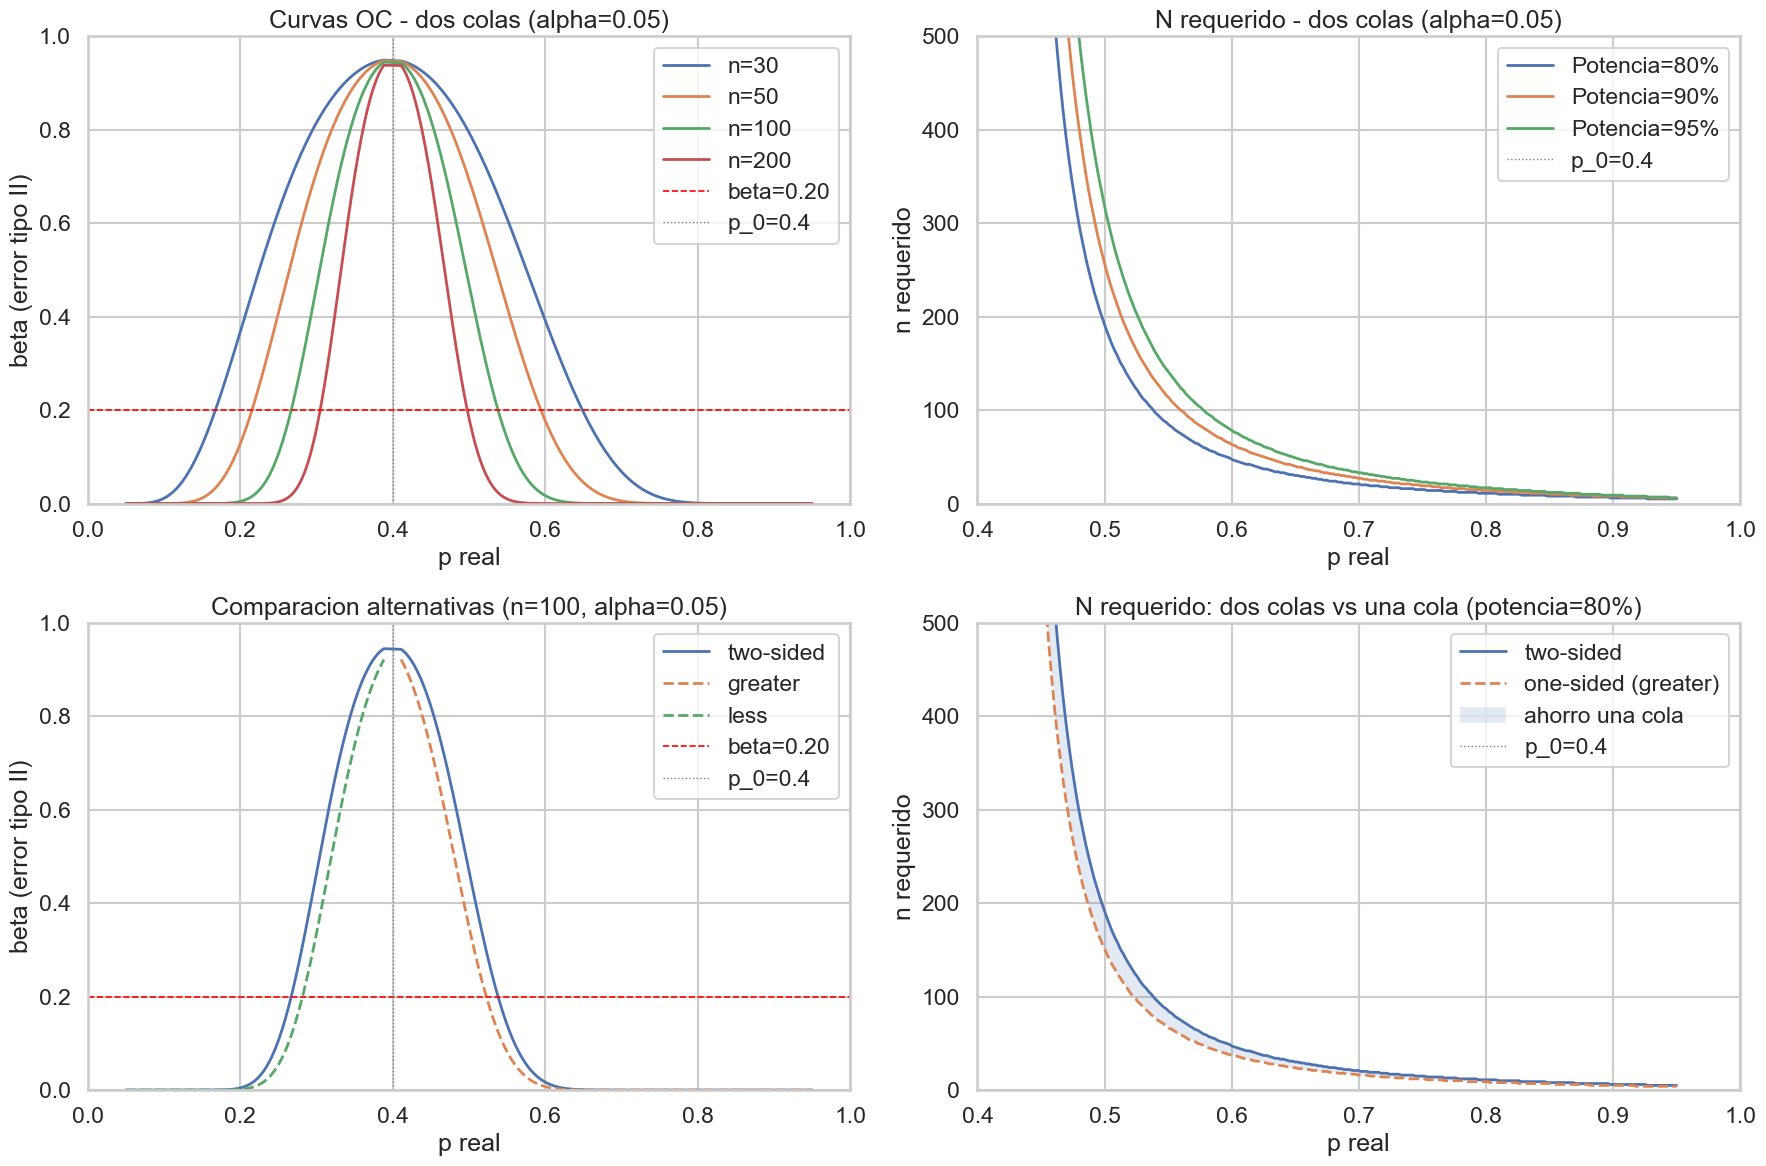

In [94]:
p_grid = np.linspace(0.05, 0.95, 400)
p_grid = p_grid[np.abs(p_grid - p_0) > 0.01]   # evitar p == p_0 (division por cero)
n_vals = [30, 50, 100, 200]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for n in n_vals:
    betas = [beta_prop(p, p_0, n, alpha, alternative='two-sided') for p in p_grid]
    axes[0, 0].plot(p_grid, betas, linewidth=2, label=f'n={n}')

axes[0, 0].axhline(0.20, color='red', linestyle='--', linewidth=1.2, label='beta=0.20')
axes[0, 0].axvline(p_0, color='gray', linestyle=':', linewidth=1, label=f'p_0={p_0}')
axes[0, 0].set_title(f'Curvas OC - dos colas (alpha={alpha})')
axes[0, 0].set_xlabel('p real')
axes[0, 0].set_ylabel('beta (error tipo II)')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()

p_grid_n = p_grid[p_grid > p_0]   # solo p > p_0 para n requerido

for potencia in [0.80, 0.90, 0.95]:
    n_reqs = [n_prop(p, p_0, 1-potencia, alpha, alternative='two-sided') for p in p_grid_n]
    axes[0, 1].plot(p_grid_n, n_reqs, linewidth=2, label=f'Potencia={int(potencia*100)}%')

axes[0, 1].axvline(p_0, color='gray', linestyle=':', linewidth=1, label=f'p_0={p_0}')
axes[0, 1].set_title(f'N requerido - dos colas (alpha={alpha})')
axes[0, 1].set_xlabel('p real')
axes[0, 1].set_ylabel('n requerido')
axes[0, 1].set_xlim(p_0, 1)
axes[0, 1].set_ylim(0, 500)
axes[0, 1].legend()

n_comp = 100
p_grid_greater = p_grid[p_grid > p_0]
p_grid_less = p_grid[p_grid < p_0]

betas_two = [beta_prop(p, p_0, n_comp, alpha, 'two-sided') for p in p_grid]
betas_greater = [beta_prop(p, p_0, n_comp, alpha, 'greater') for p in p_grid_greater]
betas_less = [beta_prop(p, p_0, n_comp, alpha, 'less') for p in p_grid_less]

axes[1, 0].plot(p_grid, betas_two, linewidth=2, label='two-sided')
axes[1, 0].plot(p_grid_greater, betas_greater, linewidth=2, linestyle='--', label='greater')
axes[1, 0].plot(p_grid_less, betas_less, linewidth=2, linestyle='--', label='less')
axes[1, 0].axhline(0.20, color='red', linestyle='--', linewidth=1.2, label='beta=0.20')
axes[1, 0].axvline(p_0, color='gray', linestyle=':', linewidth=1, label=f'p_0={p_0}')
axes[1, 0].set_title(f'Comparacion alternativas (n={n_comp}, alpha={alpha})')
axes[1, 0].set_xlabel('p real')
axes[1, 0].set_ylabel('beta (error tipo II)')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()


n_two = [n_prop(p, p_0, 0.20, alpha, 'two-sided') for p in p_grid_greater]
n_one = [n_prop(p, p_0, 0.20, alpha, 'greater')   for p in p_grid_greater]

axes[1, 1].plot(p_grid_greater, n_two, linewidth=2, label='two-sided')
axes[1, 1].plot(p_grid_greater, n_one, linewidth=2, linestyle='--', label='one-sided (greater)')
axes[1, 1].fill_between(p_grid_greater, n_one, n_two, alpha=0.15, label='ahorro una cola')
axes[1, 1].axvline(p_0, color='gray', linestyle=':', linewidth=1, label=f'p_0={p_0}')
axes[1, 1].set_title('N requerido: dos colas vs una cola (potencia=80%)')
axes[1, 1].set_xlabel('p real')
axes[1, 1].set_ylabel('n requerido')
axes[1, 1].set_xlim(p_0, 1)
axes[1, 1].set_ylim(0, 500)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Los siguientes gráficos resumen el comportamiento del error tipo II y el tamaño de muestra para la prueba de proporciones. Se organizan en cuatro paneles:

**Arriba izquierda — Curvas OC (dos colas):** Muestra $\beta$ en función de $p$ real para distintos tamaños de muestra. La curva alcanza su máximo en $p = p_0$, donde no existe diferencia real y por tanto $\beta \approx 1 - \alpha$. A medida que $p$ se aleja de $p_0$ en cualquier dirección, $\beta$ cae — la diferencia es más fácil de detectar. Curvas más bajas corresponden a $n$ mayores.

**Arriba derecha — N requerido (dos colas):** Para cada potencia objetivo, muestra cuántas observaciones se necesitan en función de $p$ real. La curva diverge cerca de $p_0$ — detectar diferencias pequeñas requiere muestras enormes — y cae rápidamente al alejarse. La línea vertical en $p_0$ marca el límite: a la izquierda la diferencia es negativa y a la derecha positiva.

**Abajo izquierda — Comparación de alternativas:** Para un $n$ fijo, compara $\beta$ entre las tres hipótesis alternativas. La prueba de dos colas siempre tiene mayor $\beta$ que la de una cola en la dirección correcta, porque distribuye $\alpha$ en ambas colas y por tanto es más exigente. Esto se traduce en que la prueba de una cola detecta mejor, **pero solo si la dirección del efecto se conoce de antemano**.

**Abajo derecha — Ahorro en N (dos colas vs una cola):** Cuantifica directamente el ahorro en tamaño de muestra al elegir una prueba de una cola. El área sombreada representa las observaciones que se ahorran. El ahorro es más pronunciado cerca de $p_0$ y se reduce a medida que la diferencia crece, porque con diferencias grandes ambos tests convergen a $n$ pequeños.